# 08 — Three-Way Model Comparison

**U-Net/ResNet34 vs FPN/ResNet34 vs SegFormer-B1**

Quantitative and qualitative comparison of 3D volumetric segmentation performance on the BraTS-PEDs test set (26 subjects).

---

## 1 — Load 3D evaluation results

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

PROJECT_ROOT = Path(".").resolve()
EVAL_DIR = PROJECT_ROOT / "evaluation_outputs"
OUT_DIR = PROJECT_ROOT / "comparison_outputs"
OUT_DIR.mkdir(exist_ok=True)

MODELS = {
    "unet":      {"label": "U-Net/ResNet34",  "color": "#4A90D9"},
    "fpn":       {"label": "FPN/ResNet34",    "color": "#50C878"},
    "segformer": {"label": "SegFormer-B1",    "color": "#E74C3C"},
}
CLASSES = ["NCR", "ED", "ET"]

data = {}
for key, meta in MODELS.items():
    path = EVAL_DIR / f"test_3d_metrics_{key}.json"
    with open(path) as f:
        data[key] = json.load(f)
    print(f"Loaded {meta['label']}: {data[key]['n_subjects']} subjects")

# Build per-subject DataFrames
dfs = {}
for key in MODELS:
    df = pd.DataFrame(data[key]["per_subject"])
    df = df.set_index("subject_id")
    # Replace near-zero values (< 1e-6) with 0 for cleaner display
    for col in df.columns:
        if df[col].dtype == float:
            df[col] = df[col].apply(lambda x: 0.0 if (x is not None and abs(x) < 1e-6) else x)
    dfs[key] = df
    
print(f"\nSubjects: {list(dfs['unet'].index[:5])} ... ({len(dfs['unet'])} total)")

Loaded U-Net/ResNet34: 26 subjects
Loaded FPN/ResNet34: 26 subjects
Loaded SegFormer-B1: 26 subjects

Subjects: ['BraTS-PED-00008-000', 'BraTS-PED-00014-000', 'BraTS-PED-00017-000', 'BraTS-PED-00032-000', 'BraTS-PED-00041-000'] ... (26 total)


## 2 — Summary table (quantitative)

In [2]:
rows = []
for cls in CLASSES:
    row = {"Class": cls}
    for key, meta in MODELS.items():
        s = data[key]["summary"][cls]
        row[f"{meta['label']} Dice"] = f"{s['dice_mean']:.4f} +/- {s['dice_std']:.4f}"
        hd = f"{s['hd95_mean']:.2f} +/- {s['hd95_std']:.2f}" if s['hd95_mean'] is not None else "N/A"
        row[f"{meta['label']} HD95"] = hd
    rows.append(row)

# Mean fg Dice row
row_fg = {"Class": "Mean FG"}
for key, meta in MODELS.items():
    row_fg[f"{meta['label']} Dice"] = f"{data[key]['summary']['mean_fg_dice']:.4f}"
    row_fg[f"{meta['label']} HD95"] = ""
rows.append(row_fg)

summary_df = pd.DataFrame(rows).set_index("Class")
print("=" * 100)
print("  3D TEST SET COMPARISON — Dice & HD95 (mean +/- std)")
print("=" * 100)
print(summary_df.to_string())
print("=" * 100)

# Architecture comparison
print("\n--- Architecture Summary ---")
arch_data = [
    {"Model": "U-Net/ResNet34",  "Params": "24.4M", "Encoder": "ResNet34", "Best Epoch": 18, "Val fg Dice": 0.8385, "Test fg Dice (3D)": 0.6164},
    {"Model": "FPN/ResNet34",    "Params": "23.2M", "Encoder": "ResNet34", "Best Epoch": 15, "Val fg Dice": 0.8461, "Test fg Dice (3D)": 0.6213},
    {"Model": "SegFormer-B1",    "Params": "13.7M", "Encoder": "MiT-B1",   "Best Epoch": 14, "Val fg Dice": 0.8554, "Test fg Dice (3D)": 0.6760},
]
print(pd.DataFrame(arch_data).set_index("Model").to_string())

  3D TEST SET COMPARISON — Dice & HD95 (mean +/- std)
        U-Net/ResNet34 Dice U-Net/ResNet34 HD95  FPN/ResNet34 Dice FPN/ResNet34 HD95  SegFormer-B1 Dice SegFormer-B1 HD95
Class                                                                                                                    
NCR       0.5856 +/- 0.3718       9.21 +/- 9.66  0.5590 +/- 0.3965     8.70 +/- 6.99  0.6752 +/- 0.3339     5.23 +/- 4.07
ED        0.7239 +/- 0.2523       7.45 +/- 6.61  0.7104 +/- 0.2380     7.63 +/- 5.76  0.7229 +/- 0.2575     8.15 +/- 8.08
ET        0.5398 +/- 0.4307      17.85 +/- 9.93  0.5946 +/- 0.4448    18.69 +/- 9.31  0.6299 +/- 0.4387    14.60 +/- 7.07
Mean FG              0.6164                                 0.6213                               0.6760                  

--- Architecture Summary ---
               Params   Encoder  Best Epoch  Val fg Dice  Test fg Dice (3D)
Model                                                                      
U-Net/ResNet34  24.4M  ResNet34 

## 3 — Dice bar chart (per class + mean FG)

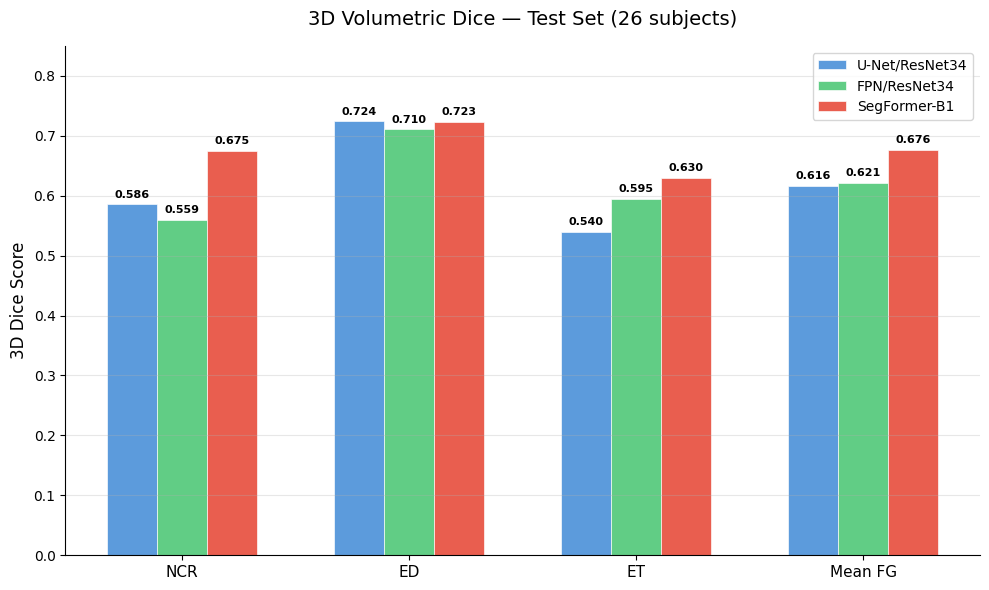

Saved -> comparison_outputs/dice_comparison_bar.png


In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

categories = CLASSES + ["Mean FG"]
x = np.arange(len(categories))
width = 0.22

for i, (key, meta) in enumerate(MODELS.items()):
    vals = [data[key]["summary"][cls]["dice_mean"] for cls in CLASSES]
    vals.append(data[key]["summary"]["mean_fg_dice"])
    bars = ax.bar(x + i * width, vals, width, label=meta["label"], color=meta["color"], 
                  edgecolor="white", linewidth=0.5, alpha=0.9)
    # Value labels
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008, f"{v:.3f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_ylabel("3D Dice Score", fontsize=12)
ax.set_title("3D Volumetric Dice — Test Set (26 subjects)", fontsize=14, pad=15)
ax.set_xticks(x + width)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 0.85)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(str(OUT_DIR / "dice_comparison_bar.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> comparison_outputs/dice_comparison_bar.png")

## 4 — Per-subject Dice box plots

C:\Users\lrnzp\AppData\Local\Temp\ipykernel_14284\2883069245.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=labels, patch_artist=True, widths=0.6,
C:\Users\lrnzp\AppData\Local\Temp\ipykernel_14284\2883069245.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=labels, patch_artist=True, widths=0.6,
C:\Users\lrnzp\AppData\Local\Temp\ipykernel_14284\2883069245.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=labels, patch_artist=True, widths=0.6,


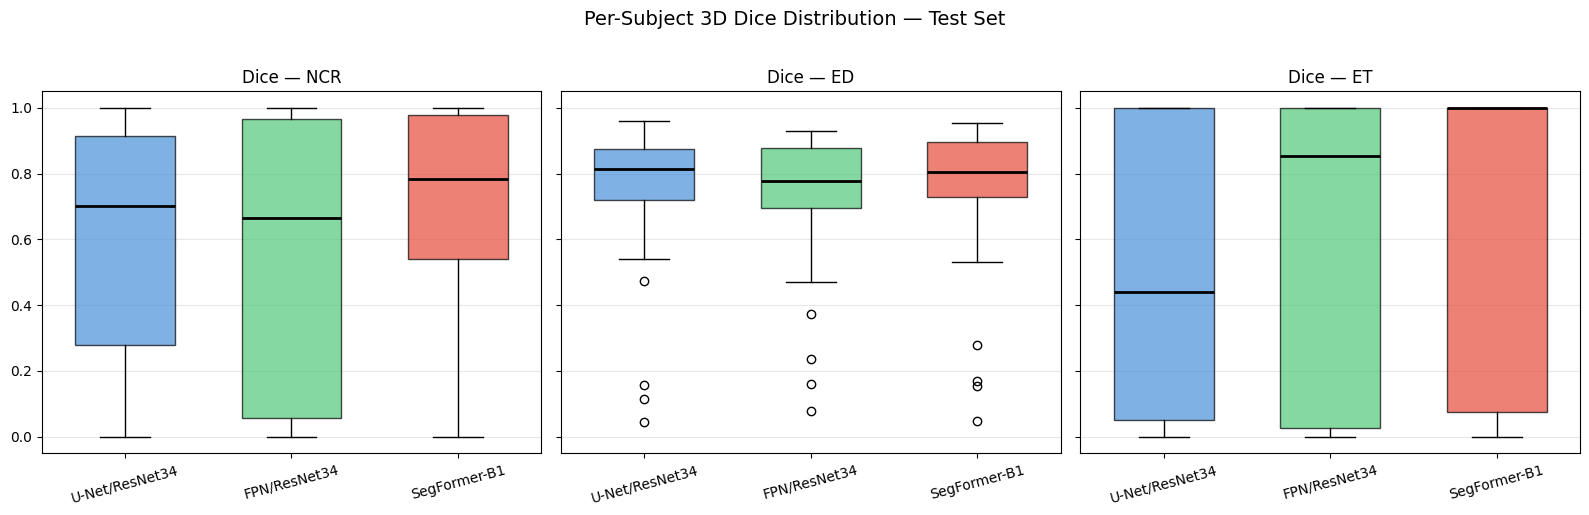

Saved -> comparison_outputs/dice_boxplot_per_class.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle("Per-Subject 3D Dice Distribution — Test Set", fontsize=14, y=1.02)

for idx, cls in enumerate(CLASSES):
    ax = axes[idx]
    col = f"dice_{cls}"
    box_data = [dfs[key][col].dropna().values for key in MODELS]
    labels = [MODELS[key]["label"] for key in MODELS]
    colors = [MODELS[key]["color"] for key in MODELS]
    
    bp = ax.boxplot(box_data, labels=labels, patch_artist=True, widths=0.6,
                    medianprops={"color": "black", "linewidth": 2})
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(f"Dice — {cls}", fontsize=12)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
fig.savefig(str(OUT_DIR / "dice_boxplot_per_class.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> comparison_outputs/dice_boxplot_per_class.png")

## 5 — HD95 comparison (bar chart)

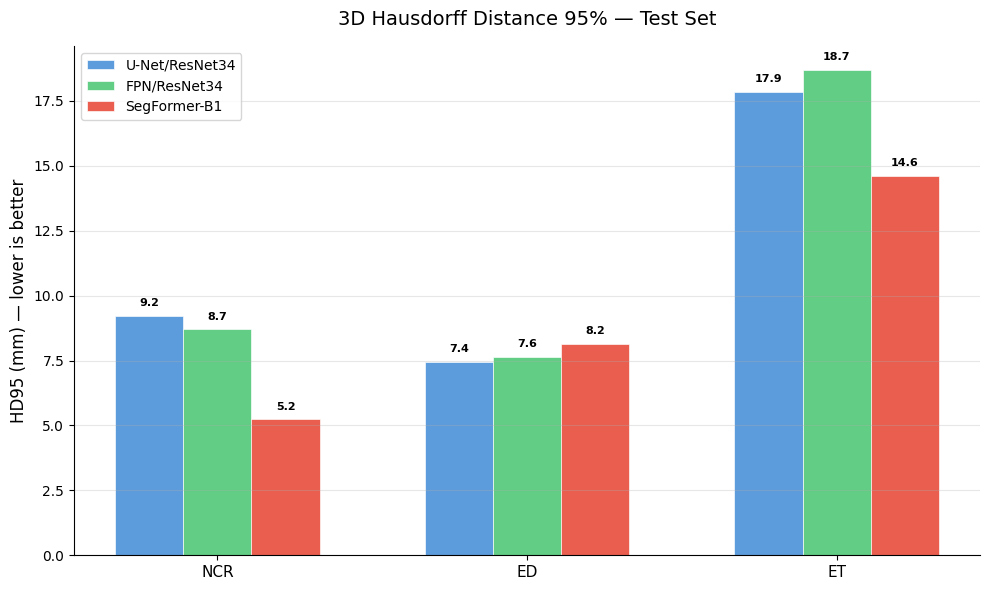

Saved -> comparison_outputs/hd95_comparison_bar.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(CLASSES))
width = 0.22

for i, (key, meta) in enumerate(MODELS.items()):
    vals = []
    for cls in CLASSES:
        s = data[key]["summary"][cls]
        vals.append(s["hd95_mean"] if s["hd95_mean"] is not None else 0)
    bars = ax.bar(x + i * width, vals, width, label=meta["label"], color=meta["color"],
                  edgecolor="white", linewidth=0.5, alpha=0.9)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f"{v:.1f}",
                    ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_ylabel("HD95 (mm) — lower is better", fontsize=12)
ax.set_title("3D Hausdorff Distance 95% — Test Set", fontsize=14, pad=15)
ax.set_xticks(x + width)
ax.set_xticklabels(CLASSES, fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(str(OUT_DIR / "hd95_comparison_bar.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> comparison_outputs/hd95_comparison_bar.png")

## 6 — Per-subject mean FG Dice scatter (paired)

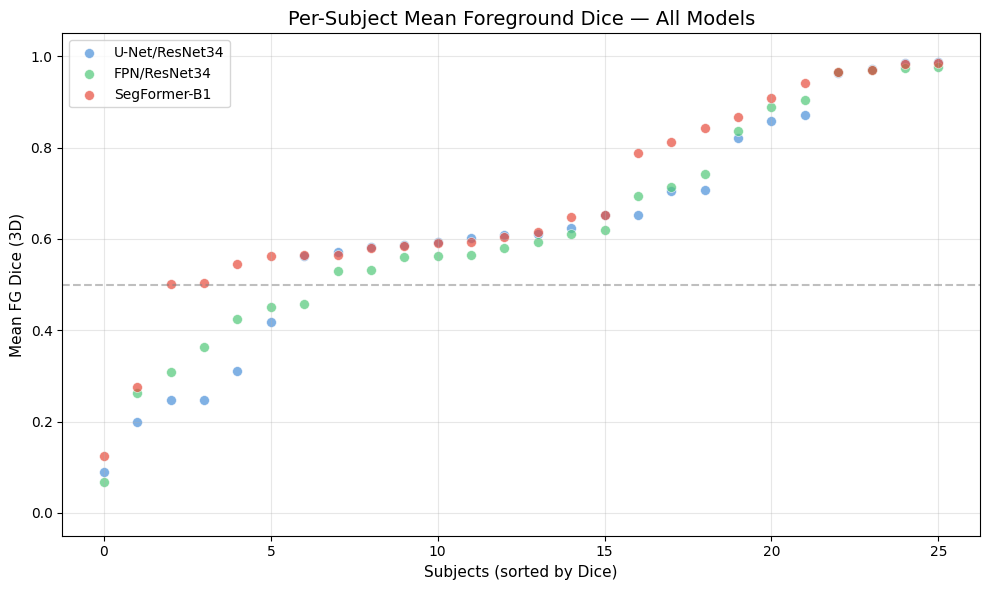

Saved -> comparison_outputs/fg_dice_scatter.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

fg_cols = [f"dice_{c}" for c in CLASSES]
for key, meta in MODELS.items():
    fg_dice = dfs[key][fg_cols].mean(axis=1).sort_values()
    ax.scatter(range(len(fg_dice)), fg_dice.values, label=meta["label"],
              color=meta["color"], alpha=0.7, s=50, edgecolors="white", linewidth=0.5)

ax.set_xlabel("Subjects (sorted by Dice)", fontsize=11)
ax.set_ylabel("Mean FG Dice (3D)", fontsize=11)
ax.set_title("Per-Subject Mean Foreground Dice — All Models", fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim(-0.05, 1.05)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="threshold")

plt.tight_layout()
fig.savefig(str(OUT_DIR / "fg_dice_scatter.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> comparison_outputs/fg_dice_scatter.png")

## 7 — Failure analysis: worst subjects per model

In [7]:
N_WORST = 5
fg_cols = [f"dice_{c}" for c in CLASSES]

print("=" * 80)
print("  FAILURE ANALYSIS — Worst subjects by mean FG Dice")
print("=" * 80)

for key, meta in MODELS.items():
    df = dfs[key].copy()
    df["mean_fg_dice"] = df[fg_cols].mean(axis=1)
    worst = df.nsmallest(N_WORST, "mean_fg_dice")
    print(f"\n--- {meta['label']} ---")
    cols_show = ["dice_NCR", "dice_ED", "dice_ET", "mean_fg_dice"]
    display_df = worst[cols_show].copy()
    for c in cols_show:
        display_df[c] = display_df[c].apply(lambda x: f"{x:.4f}")
    print(display_df.to_string())

print("\n" + "=" * 80)

  FAILURE ANALYSIS — Worst subjects by mean FG Dice

--- U-Net/ResNet34 ---
                    dice_NCR dice_ED dice_ET mean_fg_dice
subject_id                                               
BraTS-PED-00017-000   0.0643  0.0433  0.1596       0.0890
BraTS-PED-00041-000   0.0000  0.5963  0.0000       0.1988
BraTS-PED-00167-000   0.2837  0.1139  0.3422       0.2466
BraTS-PED-00154-000   0.0000  0.7405  0.0000       0.2468
BraTS-PED-00241-000   0.0000  0.9305  0.0000       0.3102

--- FPN/ResNet34 ---
                    dice_NCR dice_ED dice_ET mean_fg_dice
subject_id                                               
BraTS-PED-00017-000   0.0017  0.0794  0.1190       0.0667
BraTS-PED-00041-000   0.0000  0.7860  0.0000       0.2620
BraTS-PED-00241-000   0.0000  0.9252  0.0000       0.3084
BraTS-PED-00167-000   0.1486  0.2376  0.7046       0.3636
BraTS-PED-00032-000   0.6259  0.1601  0.4870       0.4243

--- SegFormer-B1 ---
                    dice_NCR dice_ED dice_ET mean_fg_dice
subject_id

## 8 — Agreement analysis: which subjects are hard for ALL models?

In [8]:
# Compute mean FG dice for each model
fg_all = pd.DataFrame()
for key, meta in MODELS.items():
    fg_all[meta["label"]] = dfs[key][fg_cols].mean(axis=1)

fg_all["mean_across_models"] = fg_all.mean(axis=1)
fg_all = fg_all.sort_values("mean_across_models")

print("Hardest 5 subjects (lowest mean Dice across all models):")
print(fg_all.head(5).to_string(float_format="{:.4f}".format))

print("\nEasiest 5 subjects (highest mean Dice across all models):")
print(fg_all.tail(5).to_string(float_format="{:.4f}".format))

Hardest 5 subjects (lowest mean Dice across all models):
                     U-Net/ResNet34  FPN/ResNet34  SegFormer-B1  mean_across_models
subject_id                                                                         
BraTS-PED-00017-000          0.0890        0.0667        0.1251              0.0936
BraTS-PED-00041-000          0.1988        0.2620        0.2757              0.2455
BraTS-PED-00167-000          0.2466        0.3636        0.5018              0.3707
BraTS-PED-00241-000          0.3102        0.3084        0.6488              0.4225
BraTS-PED-00154-000          0.2468        0.5632        0.5648              0.4583

Easiest 5 subjects (highest mean Dice across all models):
                     U-Net/ResNet34  FPN/ResNet34  SegFormer-B1  mean_across_models
subject_id                                                                         
BraTS-PED-00196-000          0.8585        0.9037        0.9423              0.9015
BraTS-PED-00202-000          0.9641        0

## 9 — Training convergence comparison

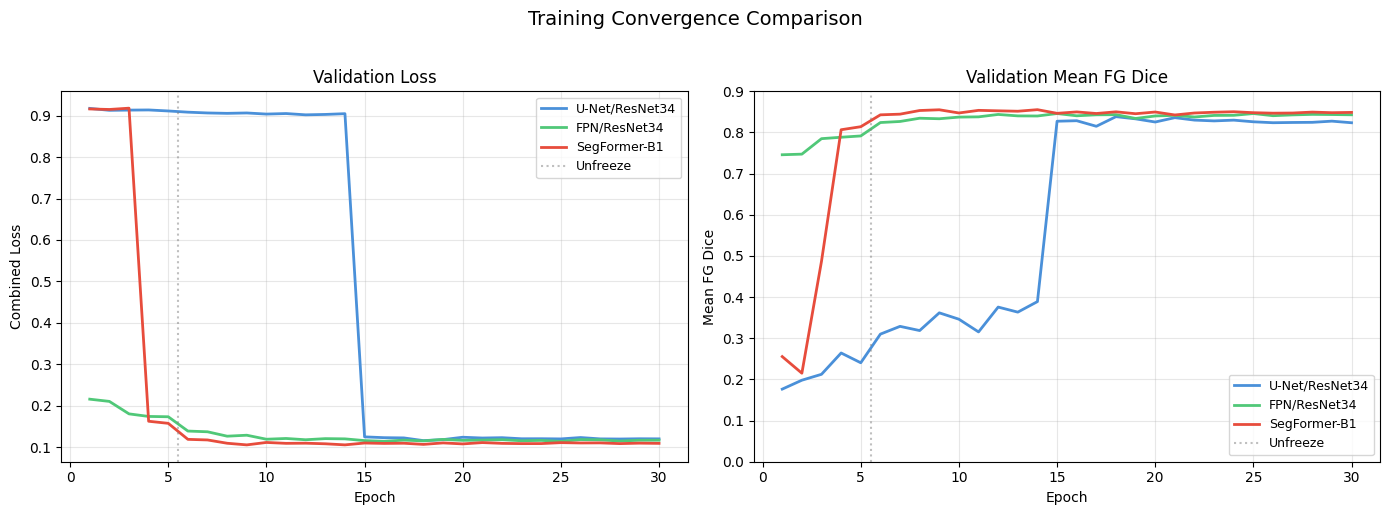

Saved -> comparison_outputs/convergence_comparison.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training Convergence Comparison", fontsize=14, y=1.02)

histories = {}
for key in ["unet", "fpn"]:
    path = PROJECT_ROOT / "checkpoints" / key / "history.json"
    with open(path) as f:
        histories[key] = json.load(f)

# Also load segformer if available
seg_path = PROJECT_ROOT / "checkpoints" / "segformer" / "history.json"
if seg_path.exists():
    with open(seg_path) as f:
        histories["segformer"] = json.load(f)

# Left: Val loss
ax = axes[0]
for key, meta in MODELS.items():
    if key in histories:
        vals = [m["loss"] for m in histories[key]["val"]]
        ax.plot(range(1, len(vals)+1), vals, label=meta["label"], color=meta["color"], linewidth=2)
ax.set_title("Validation Loss", fontsize=12)
ax.set_xlabel("Epoch")
ax.set_ylabel("Combined Loss")
ax.axvline(5.5, color="gray", linestyle=":", alpha=0.5, label="Unfreeze")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Right: Val fg Dice
ax = axes[1]
for key, meta in MODELS.items():
    if key in histories:
        vals = [np.mean([m["dice_NCR"], m["dice_ED"], m["dice_ET"]]) for m in histories[key]["val"]]
        ax.plot(range(1, len(vals)+1), vals, label=meta["label"], color=meta["color"], linewidth=2)
ax.set_title("Validation Mean FG Dice", fontsize=12)
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean FG Dice")
ax.axvline(5.5, color="gray", linestyle=":", alpha=0.5, label="Unfreeze")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(0, 0.9)

plt.tight_layout()
fig.savefig(str(OUT_DIR / "convergence_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> comparison_outputs/convergence_comparison.png")

## 10 — Save summary CSV

In [10]:
# Save full comparison DataFrame
fg_all.to_csv(str(OUT_DIR / "per_subject_fg_dice_all_models.csv"))
print(f"Saved -> comparison_outputs/per_subject_fg_dice_all_models.csv")

# Save summary table
summary_df.to_csv(str(OUT_DIR / "summary_comparison.csv"))
print(f"Saved -> comparison_outputs/summary_comparison.csv")

print("\n--- All comparison outputs saved! ---")

Saved -> comparison_outputs/per_subject_fg_dice_all_models.csv
Saved -> comparison_outputs/summary_comparison.csv

--- All comparison outputs saved! ---
